<a href="https://colab.research.google.com/github/khildasa/PengolahanCitra_2025/blob/main/Jobsheet5_KhildaSalsabilaA_PengolahanCitra_TI2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Jobsheet05 - Mengukur Kemiripan Citra dan Penerapannya dalam Pengenalan Pola**
---
Khilda Salsabila Azka || 4.33.23.0.15 || TI-2A

## Praktikum1 - Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


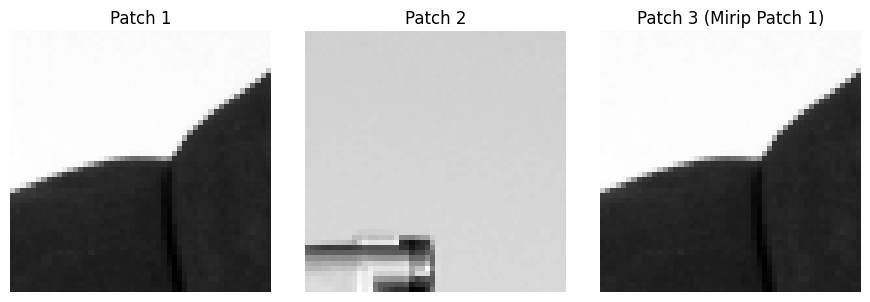

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Membuat dua patch citra sederhana atau mengambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1  # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)  # Memastikan nilai tetap di [0, 1]

# 2. Mengubah patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Menghitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Menghitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Menampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# Menampilkan visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Praktikum2 - Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


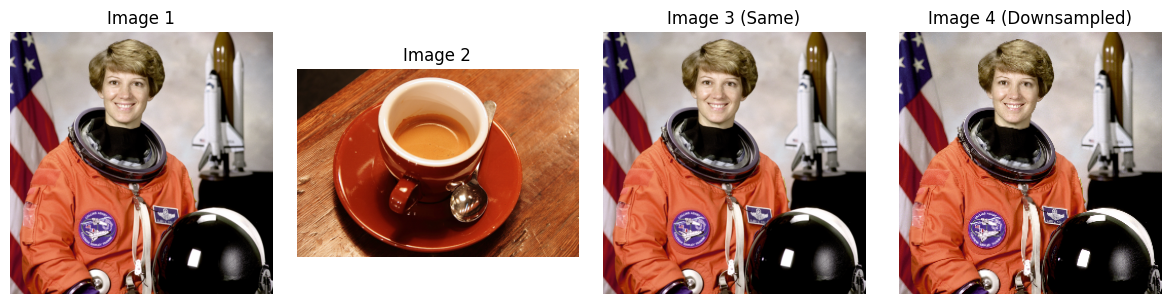

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))
    # Menggabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi histogram
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Memuat dua citra berwarna
try:
    # Menggunakan citra berbeda dari skimage
    image1 = data.astronaut()
    image2 = data.coffee()  # Citra berbeda
    image3 = data.astronaut()  # Citra sama untuk perbandingan
    image4 = image1[::2, ::2, :]  # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Menghitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Menghitung Cosine Similarity (1 - Cosine Distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Menampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# 5. Visualisasi citra
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Praktikum3 - Menghitung Structural Similarity Index (SSIM)

SSIM (Referensi vs Sama): 1.0000
SSIM (Referensi vs Noisy): 0.2959
SSIM (Referensi vs Kontras): 0.9651
SSIM (Referensi vs Blurred): 0.8027


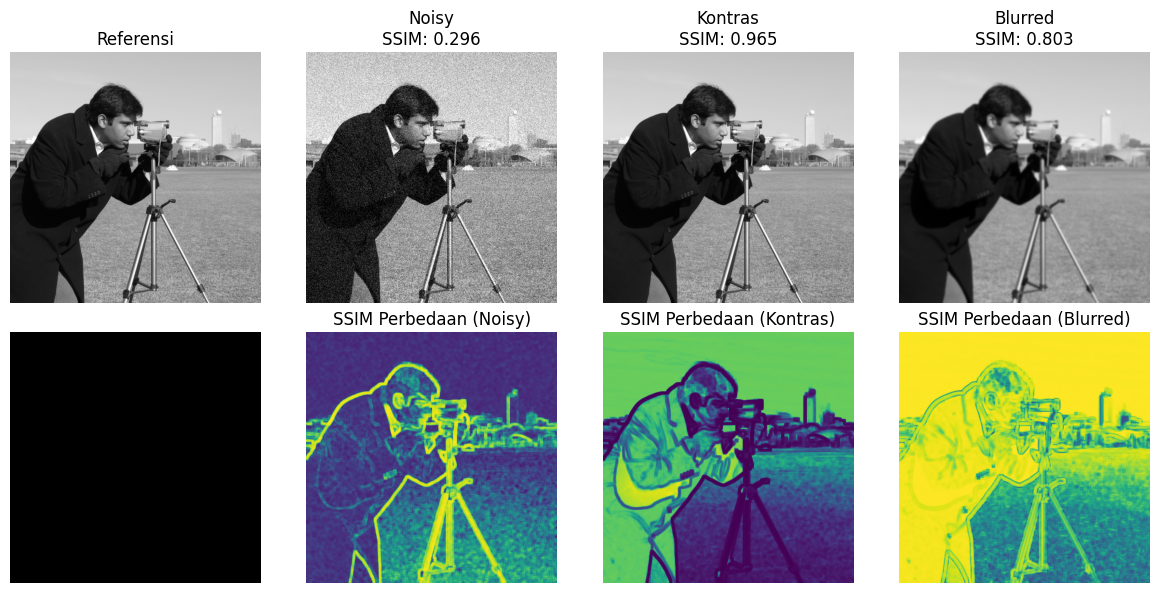

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Memuat citra referensi
image_ref = img_as_float(data.camera())

# 2. Membuat beberapa versi citra yang terdistorsi
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()
# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
# c) Citra dengan kontras berbeda
image_contrast = np.clip(image_ref * 0.8, 0, 1)
# d) Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # channel_axis=None untuk grayscale

# 3. Menghitung SSIM antara citra referensi dan citra terdistorsi
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Menampilkan hasil SSIM
print(f"SSIM (Referensi vs Sama): {ssim_same:.4f}")
print(f"SSIM (Referensi vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Referensi vs Kontras): {ssim_contrast:.4f}")
print(f"SSIM (Referensi vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi citra dan peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Menampilkan citra
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Referensi')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Kontras\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')  # Placeholder

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Perbedaan (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Perbedaan (Kontras)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Perbedaan (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.savefig('ssim_comparison.png')

## Praktikum4 - Penerapan Template Matching

Template ditemukan di koordinat (x, y): (190, 15)


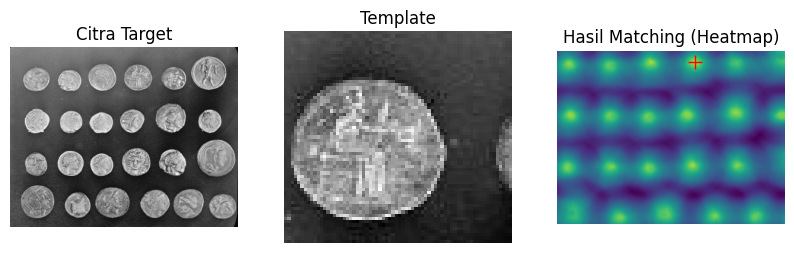

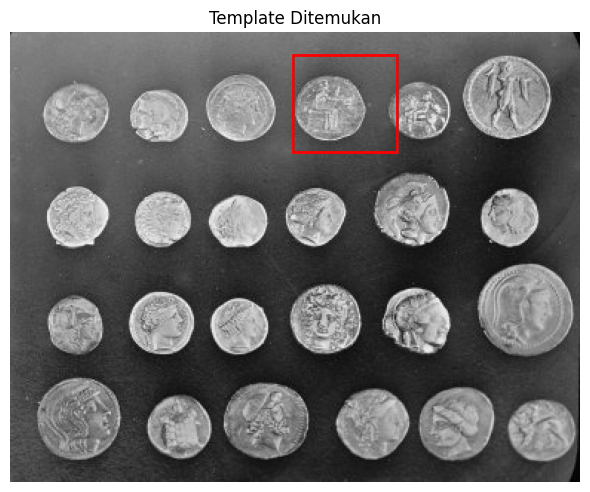

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Memuat citra target dan template
image = data.coins()
# Mengambil salah satu koin sebagai template
template = image[15:80, 190:260]

# 2. Melakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 3. Menemukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Menampilkan hasil
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

# 5. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# Menampilkan citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Citra Target')
ax[0].axis('off')

# Menampilkan template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Hasil Matching (Heatmap)')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=10)  # Menandai lokasi terbaik

# Visualisasi citra asli dengan kotak lokasi template
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Ditemukan')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.tight_layout()
plt.savefig('template_matching.png')

## Praktikum5 - Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


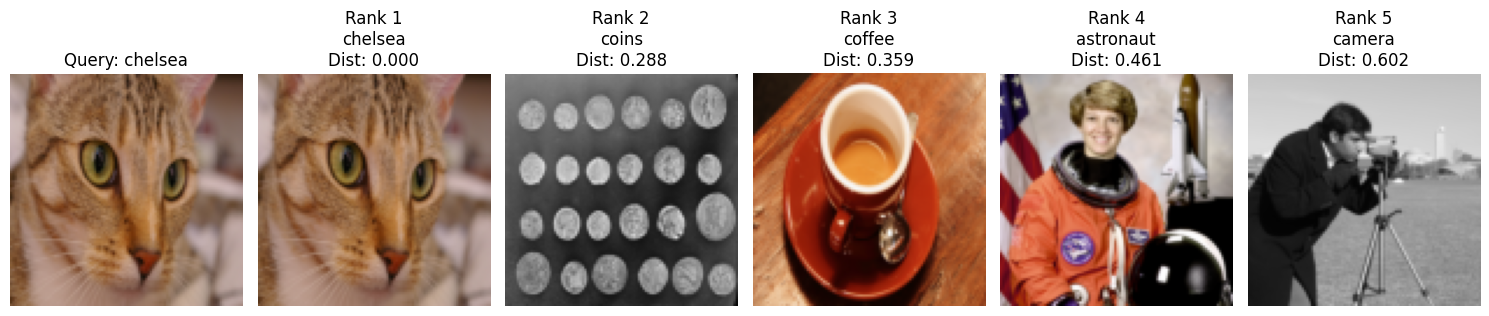

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    # Mengonversi citra float [0,1] ke uint8 [0,255] untuk histogram
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    # Menggabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Menghindari pembagian dengan nol
    return hist_combined

# 1. Menyiapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        # Memastikan citra berwarna (RGB)
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        # Mengubah ukuran citra agar fitur konsisten
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Memilih citra query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Menghitung jarak Cosine antara query dan semua citra di database
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Mengurutkan citra berdasarkan jarak (kecil ke besar)
sorted_indices = np.argsort(distances)

# 5. Menampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Menampilkan citra query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Menampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

# Mematikan axes yang tidak terpakai
for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('image_retrieval.png')

## Tugas1 - Fitur Berbeda untuk CBIR

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


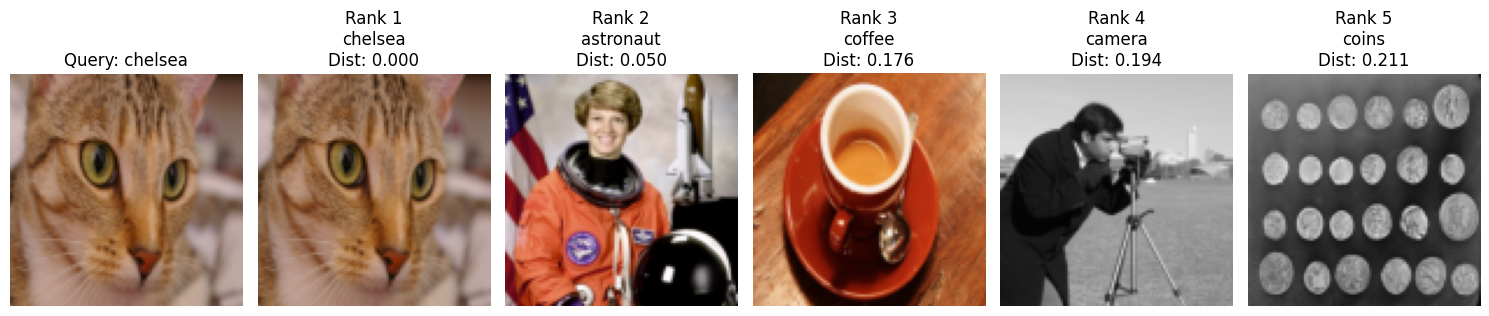

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# Fungsi untuk menghitung fitur rata-rata warna (mean R, G, B)
def calculate_mean_color(image):
    # Memastikan citra dalam format float [0, 1]
    if image.dtype != float:
        image = image.astype(float) / 255.0
    # Menghitung rata-rata intensitas untuk setiap kanal R, G, B
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# 1. Menyiapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        # Memastikan citra berwarna (RGB)
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        # Mengubah ukuran citra agar konsisten
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_features.append(calculate_mean_color(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Memilih citra query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

# 3. Menghitung jarak Euclidean antara query dan semua citra di database
distances = []
for feature in database_features:
    dist = distance.euclidean(query_feature, feature)
    distances.append(dist)

# 4. Mengurutkan citra berdasarkan jarak (kecil ke besar)
sorted_indices = np.argsort(distances)

# 5. Menampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Menampilkan citra query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Menampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

# Mematikan axes yang tidak terpakai
for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Tugas2 - Template Matching Invariant

Template Asli - Skor maksimum: 1.0000, Koordinat: (190, 15)
Template Rotasi - Skor maksimum: 0.6059, Koordinat: (226, 67)
Template Skala - Skor maksimum: 0.6072, Koordinat: (95, 45)


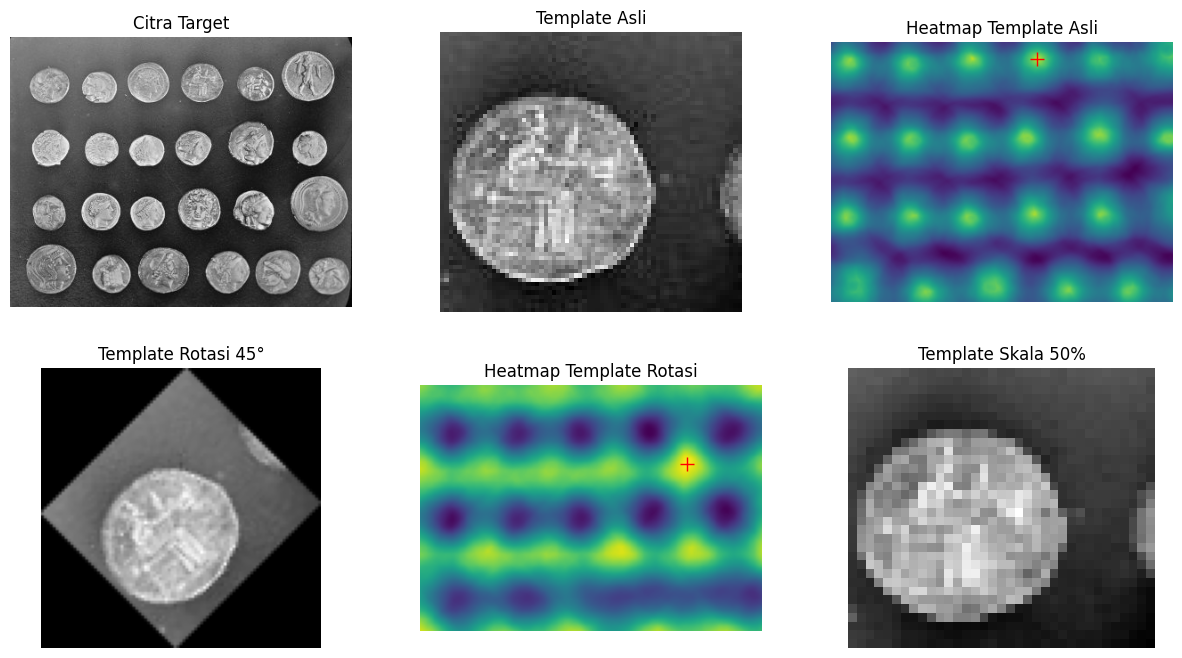

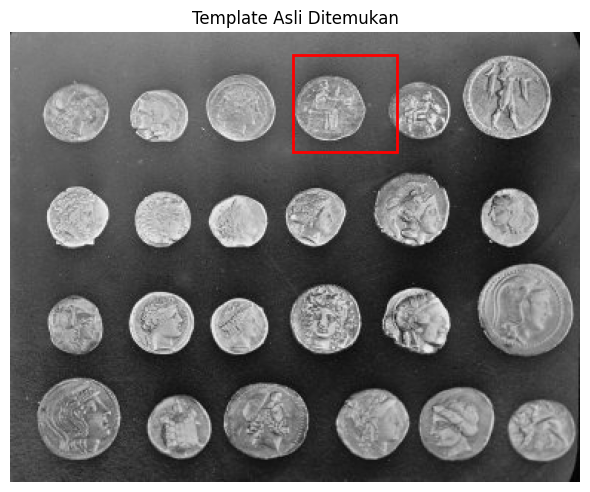

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

# 1. Memuat citra target dan template
image = data.coins()
template = image[15:80, 190:260]  # Template asli

# 2. Membuat variasi template: rotasi dan skala
template_rotated = rotate(template, angle=45, resize=True)  # Rotasi 45 derajat
template_scaled = rescale(template, scale=0.5)  # Skala 50%

# 3. Melakukan template matching untuk ketiga kasus
result_original = match_template(image, template)  # Template asli
result_rotated = match_template(image, template_rotated)  # Template dirotasi
result_scaled = match_template(image, template_scaled)  # Template diskalakan

# 4. Menemukan lokasi dengan skor matching tertinggi
ij_original = np.unravel_index(np.argmax(result_original), result_original.shape)
x_orig, y_orig = ij_original[::-1]

ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x_rot, y_rot = ij_rotated[::-1]

ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)
x_scale, y_scale = ij_scaled[::-1]

# 5. Menampilkan skor maksimum dan koordinat
print(f"Template Asli - Skor maksimum: {result_original.max():.4f}, Koordinat: ({x_orig}, {y_orig})")
print(f"Template Rotasi - Skor maksimum: {result_rotated.max():.4f}, Koordinat: ({x_rot}, {y_rot})")
print(f"Template Skala - Skor maksimum: {result_scaled.max():.4f}, Koordinat: ({x_scale}, {y_scale})")

# 6. Visualisasi hasil
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# Citra target
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Citra Target')
ax[0, 0].axis('off')

# Template asli
ax[0, 1].imshow(template, cmap='gray')
ax[0, 1].set_title('Template Asli')
ax[0, 1].axis('off')

# Heatmap template asli
ax[0, 2].imshow(result_original, cmap='viridis')
ax[0, 2].set_title('Heatmap Template Asli')
ax[0, 2].plot(x_orig, y_orig, 'r+', markersize=10)
ax[0, 2].axis('off')

# Template rotasi
ax[1, 0].imshow(template_rotated, cmap='gray')
ax[1, 0].set_title('Template Rotasi 45°')
ax[1, 0].axis('off')

# Heatmap template rotasi
ax[1, 1].imshow(result_rotated, cmap='viridis')
ax[1, 1].set_title('Heatmap Template Rotasi')
ax[1, 1].plot(x_rot, y_rot, 'r+', markersize=10)
ax[1, 1].axis('off')

# Template skala
ax[1, 2].imshow(template_scaled, cmap='gray')
ax[1, 2].set_title('Template Skala 50%')
ax[1, 2].axis('off')

# Visualisasi citra asli dengan kotak lokasi template asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Asli Ditemukan')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x_orig, y_orig), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.tight_layout()
plt.savefig('template_matching_variations.png')
plt.show()